# Association Learning: Market Basket Analysis

## Project Overview

This project uses a market basket dataset to identify products that are frequently purchased together. The goal is to apply association rule mining to discover useful shopping patterns that can support product placement, recommendation systems, cross-selling, and promotional strategies.

## Dataset Description

Each row in the dataset represents one customer transaction. The columns contain the items purchased in that transaction. Some transactions contain many items, while others contain only a few.

Unlike classification or regression, association learning does not use a target variable. Instead, it searches for relationships among items in transactions.

## Methods Used

This project applies the Apriori and FP-Growth algorithms to find frequent item sets and generate association rules. The rules are evaluated using support, confidence, lift, leverage, conviction, and Zhang's metric.

### Import libraries

In [8]:
# Run only if needed
# !pip install kagglehub mlxtend

import os
from pathlib import Path

import kagglehub
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

### Download the dataset

In [9]:
# 1. Download the dataset from KaggleHub
path = kagglehub.dataset_download("devchauhan1/market-basket-optimisationcsv")

# 2. Find the CSV file
source_path = Path(path) / "Market_Basket_Optimisation.csv"

# 3. Create local data folder
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

# 4. Copy file into your project data folder
destination_path = data_dir / "Market_Basket_Optimisation.csv"
shutil.copy(source_path, destination_path)

print(f"Dataset copied to: {destination_path}")

Dataset copied to: data/Market_Basket_Optimisation.csv


### Load the CSV file

In [13]:
df = pd.read_csv("data/Market_Basket_Optimisation.csv", header=None)

df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.shape

(7501, 20)

### Convert the dataset into transaction format

Association learning requires a list of transactions. Each transaction should be a list of purchased items.

In [14]:
transactions = []

for i in range(df.shape[0]):
    transaction = (
        df.iloc[i]
        .dropna()
        .astype(str)
        .str.strip()
        .tolist()
    )
    
    # Remove duplicate items within the same basket
    transaction = list(set(transaction))
    
    transactions.append(transaction)

# The first five customer shopping baskets.
transactions[:5]

[['antioxydant juice',
  'low fat yogurt',
  'vegetables mix',
  'almonds',
  'salmon',
  'frozen smoothie',
  'whole weat flour',
  'shrimp',
  'olive oil',
  'salad',
  'mineral water',
  'spinach',
  'green grapes',
  'cottage cheese',
  'tomato juice',
  'green tea',
  'yams',
  'honey',
  'energy drink',
  'avocado'],
 ['meatballs', 'burgers', 'eggs'],
 ['chutney'],
 ['avocado', 'turkey'],
 ['green tea', 'mineral water', 'energy bar', 'whole wheat rice', 'milk']]

In [15]:
print(f"Number of transactions: {len(transactions)}")

Number of transactions: 7501


### One-hot encode the transactions

The algorithms need a table where each column is an item and each row shows whether that item appeared in a transaction.

In [16]:
te = TransactionEncoder()

transaction_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(
    transaction_array,
    columns=te.columns_
)

basket.head()

,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,True,True,False,True,False,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [17]:
basket.shape

(7501, 119)

### Explore the most common items

In [18]:
item_frequency = basket.sum().sort_values(ascending=False)

item_frequency.head(15)

mineral water        1788
eggs                 1348
spaghetti            1306
french fries         1282
chocolate            1229
green tea             991
milk                  972
ground beef           737
frozen vegetables     715
pancakes              713
burgers               654
cake                  608
cookies               603
escalope              595
low fat yogurt        574
dtype: int64

#### Plot the top items

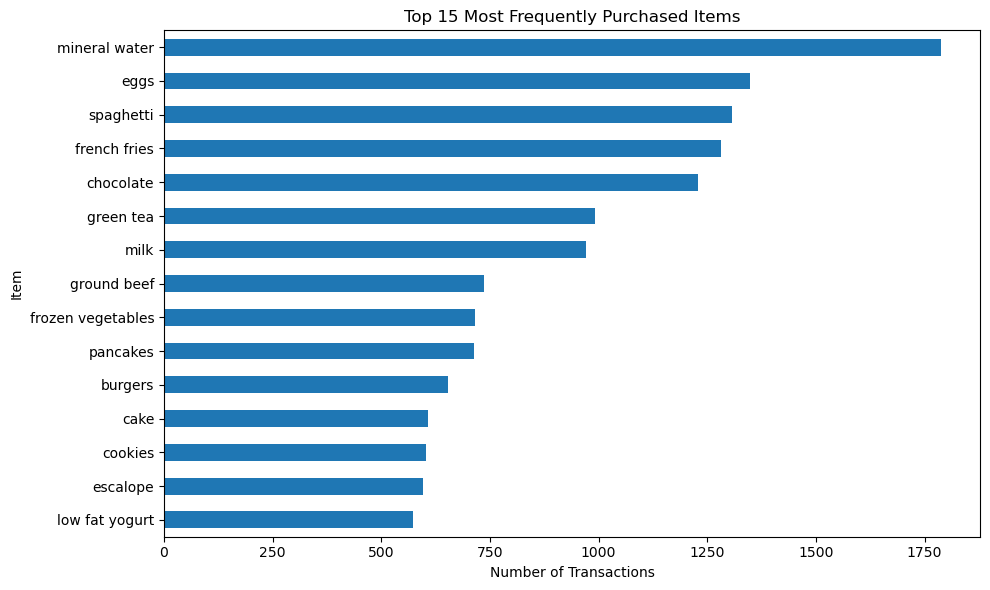

In [19]:
plt.figure(figsize=(10, 6))

item_frequency.head(15).sort_values().plot(kind="barh")

plt.xlabel("Number of Transactions")
plt.ylabel("Item")
plt.title("Top 15 Most Frequently Purchased Items")
plt.tight_layout()
plt.show()

## Key Association Rule Metrics

### Support

Support measures how often an itemset appears in all transactions.

Example: If `mineral water` appears in 20 percent of all baskets, its support is 0.20.

### Confidence

Confidence measures how often the rule is correct.

Example: If customers who buy `eggs` also buy `mineral water` 35 percent of the time, the confidence is 0.35.

### Lift

Lift compares the rule to random chance.

- Lift greater than 1 means the items are positively associated.
- Lift equal to 1 means there is no association.
- Lift less than 1 means the items are negatively associated.

### Leverage

Leverage measures how much more often two items appear together than expected if they were independent.

### Conviction

Conviction measures the strength of implication in a rule. Higher values suggest a stronger rule.

### Zhang's Metric

Zhang's metric measures the strength of association while accounting for both co-occurrence and non-co-occurrence patterns.

## Apriori Algorithm

Apriori finds item combinations that appear frequently in transactions.

The `min_support=0.003` means an itemset must appear in at least 0.3 percent of all transactions to be considered frequent. This threshold is low because many product combinations are rare in market basket data.

In [21]:
frequent_itemsets_apriori = apriori(
    basket,
    min_support=0.003,
    use_colnames=True
)

frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets_apriori.head(10)

,support,itemsets
69,0.238368,frozenset({mineral water})
34,0.179709,frozenset({eggs})
96,0.174110,frozenset({spaghetti})
40,0.170911,frozenset({french fries})
23,0.163845,frozenset({chocolate})
51,0.132116,frozenset({green tea})
68,0.129583,frozenset({milk})
52,0.098254,frozenset({ground beef})
46,0.095321,frozenset({frozen vegetables})
78,0.095054,frozenset({pancakes})


### Generate association rules with Apriori

In [22]:
rules_apriori = association_rules(
    frequent_itemsets_apriori,
    metric="lift",
    min_threshold=1.0
)

rules_apriori = rules_apriori.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

rules_apriori.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4458,"frozenset({soup, frozen vegetables})","frozenset({mineral water, milk})",0.007999,0.047994,0.003066,0.383333,7.987176,1.0,0.002682,1.543794,0.881853,0.057935,0.352245,0.223611
4455,"frozenset({mineral water, milk})","frozenset({soup, frozen vegetables})",0.047994,0.007999,0.003066,0.063889,7.987176,1.0,0.002682,1.059704,0.918901,0.057935,0.056341,0.223611
3917,"frozenset({frozen vegetables, olive oil})","frozenset({mineral water, milk})",0.011332,0.047994,0.003333,0.294118,6.128268,1.0,0.002789,1.348676,0.846413,0.059524,0.258532,0.181781
3920,"frozenset({mineral water, milk})","frozenset({frozen vegetables, olive oil})",0.047994,0.011332,0.003333,0.069444,6.128268,1.0,0.002789,1.062449,0.879009,0.059524,0.058779,0.181781
2932,"frozenset({mineral water, whole wheat pasta})",frozenset({olive oil}),0.009599,0.065858,0.003866,0.402778,6.115863,1.0,0.003234,1.564145,0.844598,0.054004,0.360673,0.230741
2937,frozenset({olive oil}),"frozenset({mineral water, whole wheat pasta})",0.065858,0.009599,0.003866,0.058704,6.115863,1.0,0.003234,1.052168,0.895464,0.054004,0.049582,0.230741
4413,"frozenset({frozen vegetables, chocolate})","frozenset({mineral water, shrimp})",0.022930,0.023597,0.003200,0.139535,5.913283,1.0,0.002658,1.134739,0.850389,0.073846,0.118740,0.137564
4408,"frozenset({mineral water, shrimp})","frozenset({frozen vegetables, chocolate})",0.023597,0.022930,0.003200,0.135593,5.913283,1.0,0.002658,1.130336,0.850969,0.073846,0.115307,0.137564
4457,"frozenset({soup, milk})","frozenset({mineral water, frozen vegetables})",0.015198,0.035729,0.003066,0.201754,5.646864,1.0,0.002523,1.207988,0.835610,0.064067,0.172177,0.143788
4456,"frozenset({mineral water, frozen vegetables})","frozenset({soup, milk})",0.035729,0.015198,0.003066,0.085821,5.646864,1.0,0.002523,1.077253,0.853401,0.064067,0.071713,0.143788


### A cleaner rules for readability

In [23]:
def format_itemset(itemset):
    return ", ".join(list(itemset))


rules_apriori_clean = rules_apriori.copy()

rules_apriori_clean["antecedents"] = rules_apriori_clean["antecedents"].apply(format_itemset)
rules_apriori_clean["consequents"] = rules_apriori_clean["consequents"].apply(format_itemset)

rules_apriori_clean[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction",
        "zhangs_metric"
    ]
].head(15)

,antecedents,consequents,support,confidence,lift,leverage,conviction,zhangs_metric
4458,"soup, frozen vegetables","mineral water, milk",0.003066,0.383333,7.987176,0.002682,1.543794,0.881853
4455,"mineral water, milk","soup, frozen vegetables",0.003066,0.063889,7.987176,0.002682,1.059704,0.918901
3917,"frozen vegetables, olive oil","mineral water, milk",0.003333,0.294118,6.128268,0.002789,1.348676,0.846413
3920,"mineral water, milk","frozen vegetables, olive oil",0.003333,0.069444,6.128268,0.002789,1.062449,0.879009
2932,"mineral water, whole wheat pasta",olive oil,0.003866,0.402778,6.115863,0.003234,1.564145,0.844598
2937,olive oil,"mineral water, whole wheat pasta",0.003866,0.058704,6.115863,0.003234,1.052168,0.895464
4413,"frozen vegetables, chocolate","mineral water, shrimp",0.003200,0.139535,5.913283,0.002658,1.134739,0.850389
4408,"mineral water, shrimp","frozen vegetables, chocolate",0.003200,0.135593,5.913283,0.002658,1.130336,0.850969
4457,"soup, milk","mineral water, frozen vegetables",0.003066,0.201754,5.646864,0.002523,1.207988,0.835610
4456,"mineral water, frozen vegetables","soup, milk",0.003066,0.085821,5.646864,0.002523,1.077253,0.853401


### Filter strong rules

A useful rule should usually have reasonable support, confidence, and lift.

In [25]:
strong_rules_apriori = rules_apriori_clean[
    (rules_apriori_clean["support"] >= 0.003) &
    (rules_apriori_clean["confidence"] >= 0.20) &
    (rules_apriori_clean["lift"] > 2.0)
].copy()

strong_rules_apriori = strong_rules_apriori.sort_values(
    by=["lift", "confidence"],
    ascending=False
)

strong_rules_apriori.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4458,"soup, frozen vegetables","mineral water, milk",0.007999,0.047994,0.003066,0.383333,7.987176,1.0,0.002682,1.543794,0.881853,0.057935,0.352245,0.223611
3917,"frozen vegetables, olive oil","mineral water, milk",0.011332,0.047994,0.003333,0.294118,6.128268,1.0,0.002789,1.348676,0.846413,0.059524,0.258532,0.181781
2932,"mineral water, whole wheat pasta",olive oil,0.009599,0.065858,0.003866,0.402778,6.115863,1.0,0.003234,1.564145,0.844598,0.054004,0.360673,0.230741
4457,"soup, milk","mineral water, frozen vegetables",0.015198,0.035729,0.003066,0.201754,5.646864,1.0,0.002523,1.207988,0.835610,0.064067,0.172177,0.143788
4829,tomato sauce,"spaghetti, ground beef",0.014131,0.039195,0.003066,0.216981,5.535971,1.0,0.002512,1.227052,0.831108,0.061008,0.185039,0.147606
4452,"mineral water, frozen vegetables, milk",soup,0.011065,0.050527,0.003066,0.277108,5.484407,1.0,0.002507,1.313438,0.826814,0.052392,0.238639,0.168897
4076,fromage blanc,honey,0.013598,0.047460,0.003333,0.245098,5.164271,1.0,0.002688,1.261806,0.817478,0.057737,0.207485,0.157661
4826,"tomato sauce, spaghetti",ground beef,0.006266,0.098254,0.003066,0.489362,4.980600,1.0,0.002451,1.765920,0.804260,0.030223,0.433723,0.260285
2157,light cream,chicken,0.015598,0.059992,0.004533,0.290598,4.843951,1.0,0.003597,1.325072,0.806131,0.063790,0.245324,0.183077
1298,pasta,escalope,0.015731,0.079323,0.005866,0.372881,4.700812,1.0,0.004618,1.468107,0.799853,0.065770,0.318851,0.223415


Rules are filtered to focus on patterns that are frequent enough, reliable enough, and stronger than random chance. A lift greater than 2 means the consequent is at least twice as likely when the antecedent is present compared with its overall occurrence.

## FP Growth Algorithm